In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import sbibm

from pyro_cases.run import train_and_test

In [3]:
device = torch.device("cuda:7")

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
# torch.autograd.set_detect_anomaly(True)

In [6]:
out_dict = train_and_test(task_name="gaussian_linear",
                          seed=12345,
                          device=device,
                          lr=1e-3,
                          lr_schedule="cosine_annealing_warm_restart",
                          num_particles=1,
                          vectorize_particles=False,
                          batch_size=2048,
                          network_width=1024,
                          steps=10_000,
                          show_progress=True)

100%|██████████| 10000/10000 [02:39<00:00, 62.72it/s]


[12345 completes] cost time: 159.5 seconds


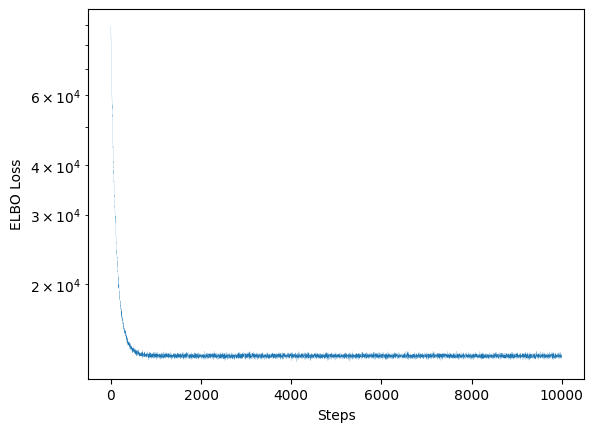

In [7]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.show()

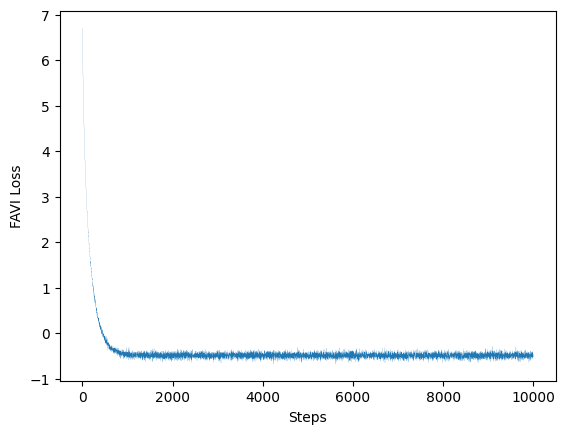

In [8]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
# plt.yscale("log")
plt.show()

In [9]:
out_dict["elbo_test_dict_list"][0]["obs_seed"]

10000

In [10]:
out_dict["elbo_test_dict_list"][0]["obs"]

tensor([[ 0.3526, -0.1561, -0.4935,  0.5363, -0.0467,  0.0602,  0.2182, -0.1278,
          0.5581, -0.4149]])

In [11]:
out_dict["elbo_test_dict_list"][0]["true_theta"]

tensor([ 0.6951, -0.1654,  0.0374,  0.3682,  0.1402, -0.2768,  0.1937,  0.1329,
        -0.0719, -0.4206])

In [12]:
out_dict["elbo_test_dict_list"][0]["est_mu"]

tensor([ 0.2187, -0.1000, -0.3044,  0.3240, -0.0327,  0.0355,  0.1324, -0.0732,
         0.3504, -0.2590])

In [13]:
out_dict["elbo_test_dict_list"][0]["est_sigma2"]

tensor([0.0590, 0.0587, 0.0593, 0.0599, 0.0590, 0.0588, 0.0591, 0.0589, 0.0595,
        0.0589])

In [14]:
out_dict["favi_test_dict_list"][0]["obs_seed"]

10000

In [15]:
out_dict["favi_test_dict_list"][0]["obs"]

tensor([[ 0.3526, -0.1561, -0.4935,  0.5363, -0.0467,  0.0602,  0.2182, -0.1278,
          0.5581, -0.4149]])

In [16]:
out_dict["favi_test_dict_list"][0]["true_theta"]

tensor([ 0.6951, -0.1654,  0.0374,  0.3682,  0.1402, -0.2768,  0.1937,  0.1329,
        -0.0719, -0.4206])

In [17]:
out_dict["favi_test_dict_list"][0]["est_mu"]

tensor([ 0.2284, -0.1036, -0.3131,  0.3431, -0.0345,  0.0368,  0.1361, -0.0765,
         0.3585, -0.2684])

In [18]:
out_dict["favi_test_dict_list"][0]["est_sigma2"]

tensor([0.0641, 0.0639, 0.0642, 0.0647, 0.0638, 0.0640, 0.0641, 0.0640, 0.0644,
        0.0641])